### Name: Silva Alejandro
### Affiliation: Yachay Tech University, School of Physical Sciences and Nanotechnology
### Class: Dynamical Systems, lectured by Prof. Mario Cosenza.
### Date: April 2026
### Mail: alejandro.silva@yachaytech.edu.ec
---

# 1. Consider the unidimensional map,
$$
x_{n+1} = f(x_n) = b x_n - x_n^3.
$$
Find the fixed points and their stability as functions of *b*.

The fixed points are given when the next state is equal to the current state in iterated maps. Then,
$$
f(x_{m}) = bx_{m} - x_{m}^{3}= x_{m},
$$
$$
x_{m}((b - 1) - x_{m}^{2})= 0,
$$
$$
\Rightarrow x_{1}^* = 0, x_{2}^* = \pm \sqrt{b - 1}.
$$

To do analyze their stability we find the behavior of the derivative of the map at the fixed points.
$$
f'(x_{n}) = b - 3 x_{n}^{2},
$$
- **$x_{1}^* = 0$:**
$$
f'(x_{1}^*) = b.
$$
This fixed point is stabe iff,
$$|b| < 1,$$
$$-1 < b < 1.$$
- **$x_{2}^* = \pm \sqrt{b - 1}$:**
$$
f'(x_{2}^*) = 3 - 2 b,
$$
This fixed point is stabe iff,
$$|3 - 2 b| < 1,$$
$$1 < b < 2.$$


---
# 2. Consider the map,  
$$
x_{n+1} = b + \frac{a x_n}{x_n^2 + 1}, \quad (a, b) > 0.
$$

For the fixed value $a = 11.5$, obtain the bifurcation diagram of the map as a function of  $b \in [-5, 0]$.

In [1]:
# Import libraries
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
import scienceplots

# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

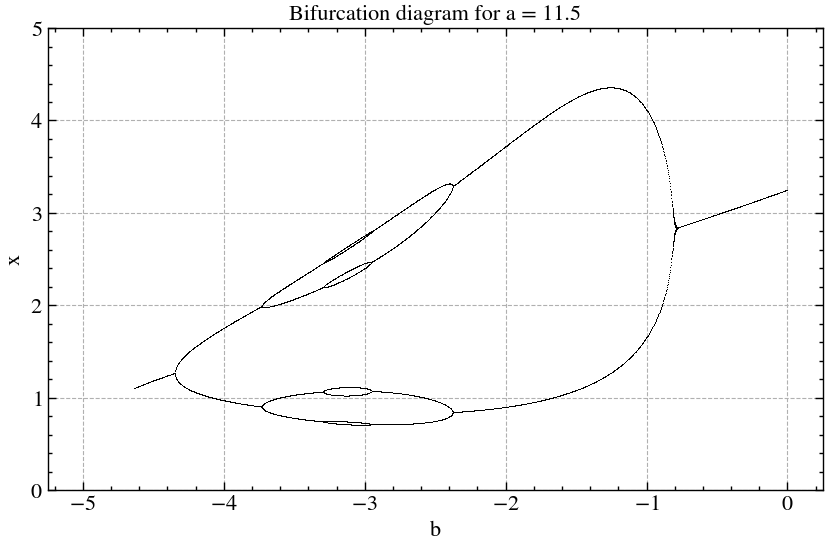

In [2]:
# Set the value of a
a = 11.5

# Define the map
def map2(x_old, a, b):
    '''
    Discrete map.
    '''
    return b + a*x_old/(x_old**2 + 1)

# Range of b values
b_values = np.linspace(-5, 0, 2000)

# Iteration settings
n_transient = 600    # throw away these
n_keep = 200         # plot these
x0 = 1.5         # initial condition

# Lists to store points
B_plot = []
X_plot = []

for b in b_values:
    # Start with initial condition
    x = x0
    
    # First iterate over the elements we'll remove
    for _ in range(n_transient):
        x = map2(x, a, b)
    
    # Then, using the last x iterate for the number of elements we want to keep
    for _ in range(n_keep):
        x = map2(x, a, b)
        # Append results to lists
        B_plot.append(b)
        X_plot.append(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(B_plot, X_plot, ',k', alpha=0.8)
plt.xlabel('b')
plt.ylabel('x')
plt.ylim(0, 5)
plt.title(f'Bifurcation diagram for a = {a}')
plt.grid(True, linestyle="--", linewidth=0.8)
plt.show()

---
# 3. The Newton-Raphson's method to find roots of the equation $f(x) = 0$ involves the iteration of the map,
$$
x_{n+1} = N(x_n) = x_n - \frac{f(x_n)}{f'(x_n)},
$$
starting from an initial estimate root $x_0$.

### a) Show that the roots of $f(x) = 0$ correspond to stable fixed points of the map $N(x_n)$.

The fixed points of the map $N(x_n)$ are given by,
$$
N(x_m) = x_m - \frac{f(x_m)}{f'(x_m)} = x_m,
$$
$$
-\frac{f(x_m)}{f'(x_m)} = 0,
$$
$$
f(x_m)= 0;
$$
which correspond to the roots of $f(x)$, provided $f'(x) \neq 0$. Now, to study stability we compute $N'(x)$ and evaluate it at the fixed point.
$$
N'(x) = 1 - (1 - \frac{f(x) f''(x)}{(f'(x))²}),
$$
$$
\Rightarrow N'(x_m) = \frac{f(x_m) f''(x_m)}{(f'(x_m))²}),
$$
$$
N'(x_m) = 0 < 1;
$$
since $f(x_m) = 0$. And these fixed points are stable because $|N'(x_m)| < 1$.

### b) By using this method, find the fixed points of the map
$$
x_{n+1} = 1.5 + \ln |x_n|.
$$

The fixed points of a one-dimensional map $x_{n+1} = G(x_n)$ are the solutions of $G(x) = x$.
This can be rewritten as $f(x) = G(x)−x = 0$.
Therefore, the fixed points of the map correspond to the roots of $f(x)$, which can be found using Newton-Raphson’s method.

We rewrite the map as a fixed point equation where, $f(x) = 1.5 + ln|x| - x = 0$. Then, we implement the Newton-Raphson's method.

In [3]:
# Define the map
def newton_map(x):
    '''
    Implementation of the Newton-Raphson's method to find the roots of f(x) = 1.5 + ln|x| - x.
    Note that, f'(x) = 1/x - 1.
    '''
    return x - (1.5 + np.log(abs(x)) - x)/(1/x - 1)
    
# Iteration
x = 0.5 # initial condition

for i in range(10):
    x = newton_map(x)
    print(f"Iteration: {i}, Fixed point: {x}")

Iteration: 0, Fixed point: 0.1931471805599453
Iteration: 1, Fixed point: 0.2739271050626868
Iteration: 2, Fixed point: 0.29989110976469047
Iteration: 3, Fixed point: 0.3017017194762167
Iteration: 4, Fixed point: 0.30170956253834325
Iteration: 5, Fixed point: 0.301709562684336
Iteration: 6, Fixed point: 0.301709562684336
Iteration: 7, Fixed point: 0.301709562684336
Iteration: 8, Fixed point: 0.301709562684336
Iteration: 9, Fixed point: 0.301709562684336


After a few iterations, the method converges to a fixed point. Its value depends on the initial condition.

---
# 4. Consider the map,
$$
x_{n+1} = \sin^2\left( r \arcsin(\sqrt{x_n}) \right), \quad \text{for } x_n \in [0,1].
$$

### a) Obtain the bifurcation diagram for $r \in [1,4]$.

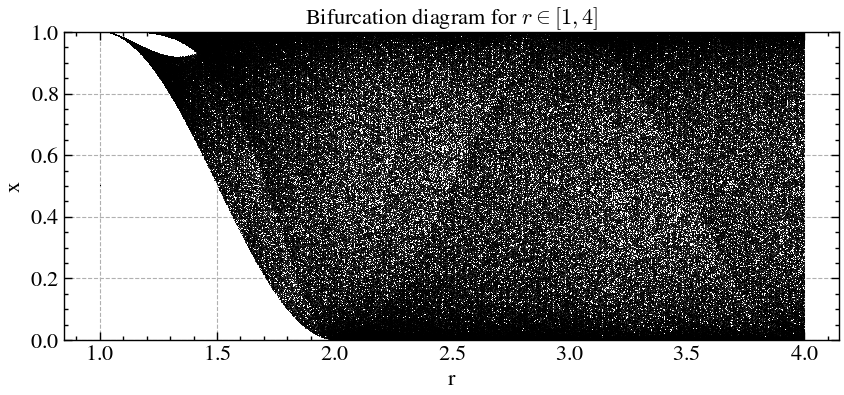

In [4]:
# Define the map
def map4(x_old, r):
    '''
    Discrete map.
    '''
    return np.sin(r*np.arcsin(np.sqrt(x_old)))**2

# Range of r values
r_values = np.linspace(1, 4, 2000)

# Iteration settings
n_transient = 600    # throw away these
n_keep = 300         # plot these
x0 = 0.5    # initial condition

# Lists to store points
r_plot = []
X_plot = []

for r in r_values:
    # Start with initial condition
    x = x0
    
    # First iterate over the elements we'll remove
    for _ in range(n_transient):
        x = map4(x, r)
    
    # Then, using the last x iterate for the number of elements we want to keep
    for _ in range(n_keep):
        x = map4(x, r)
        # Append results to lists
        r_plot.append(r)
        X_plot.append(x)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(r_plot, X_plot, ',k', alpha=0.8)
plt.xlabel('r')
plt.ylabel('x')
plt.ylim(0, 1)
plt.title(r'Bifurcation diagram for $r \in [1,4]$')
plt.grid(True, linestyle="--", linewidth=0.8)
plt.show()

### b) Calculate the Lyapunov exponent as a function of $r$, for $r \in [1,4]$.
To compute the Lyapunov exponent we use the formula,
$$
\lambda = \lim_{N \to \infty} \frac{1}{N} \sum_{n=0}^{N-1} \ln \left| f'(x_n) \right|.
$$
So, we need to compute the derivative of $f(x_n) = \sin^2\left( r \arcsin(\sqrt{x_n}) \right), \quad \text{for } x_n \in [0,1].$ 

In [5]:
# Define symbols
x, r = sy.symbols('x r', positive=True)

# Define the function
f = sy.sin(r * sy.asin(sy.sqrt(x)))**2

# Compute derivative
df = sy.diff(f, x)
df_sy = sy.simplify(df)
# Print
print(f"The derivative of the given f(x) is:")
display(df_sy)

The derivative of the given f(x) is:


r*sin(2*r*asin(sqrt(x)))/(2*sqrt(x)*sqrt(1 - x))

In [6]:
# Derivative
def deriv4(x, r):
    '''
    Derivative from the definition of the Lyapunov exponent.
    '''
    return (r * np.sin(2 * r * np.arcsin(np.sqrt(x)))) / (2 * np.sqrt(x + 1e-9) * np.sqrt(1 - x + 1e-9))

# Lyapunov exponent
def lyapunov(r, x0=0.7, N=5000, transient=4000):
    '''
    Numerical Lyapunov exponent for a given r.
    '''
    # Initial condition
    x = x0
    
    # Remove transient
    for _ in range(transient):
        x = map4(x, r)
    
    # Compute sum
    sum_ls = 0.0
    for _ in range(N):
        # Derivative of the map
        d = deriv4(x, r)
        # Sum
        sum_ls += np.log(abs(d + 0.0001))
        # Compute map for next iteration
        x = map4(x, r)

    return sum_ls / N

# Compute the Lyapunov exponent
lyap_values = np.array([lyapunov(r) for r in r_values])

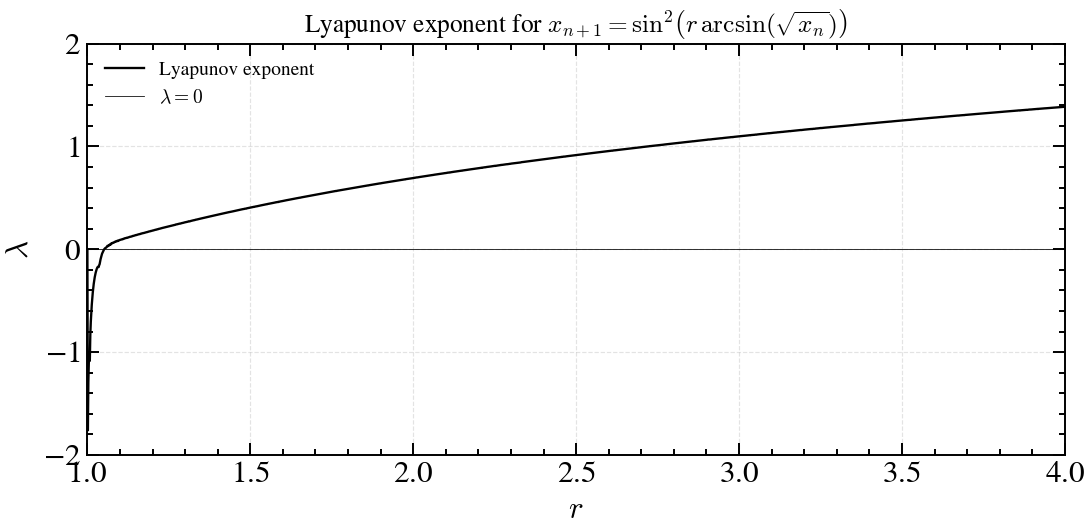

In [7]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 4), dpi=140)

ax.plot(r_values, lyap_values, color='k', linewidth=1.2, label='Lyapunov exponent')
ax.axhline(0, color='k', ls='-', lw=0.4, label=r'$\lambda = 0$')

ax.set_xlim(1, 4)
ax.set_ylim(-2, 2)
ax.set_xlabel(r'$r$', fontsize=16)
ax.set_ylabel(r'$\lambda$', fontsize=16)
ax.set_title(r'Lyapunov exponent for $x_{n+1}=\sin^2\!\left(r \, \arcsin(\sqrt{x_n})\right)$', fontsize=13)

ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.35)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

---
# 5. Let $r_n^*$ be the parameter value of a quadratic map $f_r(x)$ for which there exists a superstable orbit of period $2^n$.

### a) Consider an arbitrary function $h(r_n^*)$ evaluated at $r_n^*$. Show that, for $n \gg 1$, $h(r)$ satisfies the relation,
$$
\frac{[h(r_n^*) - h(r_\infty)]\,\delta^n}{h'(r_\infty)} = \text{cte.}
$$

### b) Show that, for $n \gg 1$,
$$
(r_n^* - r_\infty)\,\delta^n \propto \frac{\delta^2}{\delta - 1}.
$$

---
# 6. Consider the following map for $x_n \in [0,1]$:
$$
x_{n+1} = f(x_n) =
\begin{cases}
(1+\epsilon)x_n + x_n^2, & \text{if } x_n < x^*, \\
(1-x_n), & \text{if } x_n > x^*,
\end{cases}
$$
where $x^*$ is the solution of $(1+\epsilon)x^* + x^{*2} = 1.$

### a) Plot the iterates $x_n$ versus $n$ for $\epsilon = 0.08$.

### b) Plot the bifurcation diagram $x_n$ as a function of $\epsilon \in [-0.4,0.4]$. Describe the route to chaos exhibited by this map on this interval of $\epsilon$.